<div style="background-color:#E8F6F3; padding:20px; border-left:8px solid #27AE60; border-radius:8px">

## **1er EDA: Proyecto Airbnb en Nueva York**

**Autor:** Anais Aponte  
**Bootcamp:** 4Geeks Academy – Intro to Machine Learning  
**Proyecto:** Proyecto de Preprocesamiento de Datos  

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### 📝 **Instrucciones**

#### **Realizar un Analisis Exploratorio de Datos Completo**

Una empresa ha recolectado la información del alquiler de viviendas en Nueva York a través de la aplicación Airbnb durante el año 2019. Este conjunto de datos se utilizó para entrenar modelos de Machine Learning durante ese año, en una competición en abierto.

Ahora lo utilizaremos para llevar a cabo un estudio acerca de las variables que componen el dataset a fin de comprenderlo y obtener conclusiones sobre él.

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

## 📝 **Paso 1: Carga del conjunto de datos**

El dataset utilizado en este proyecto es **AB_NYC_2019.csv**.

Para facilitar la reproducibilidad y evitar dependencias externas, el archivo ha sido previamente descargado y almacenado dentro del repositorio en la siguiente ruta:

📁 `data/raw/AB_NYC_2019.csv`

De esta forma, el notebook puede ejecutarse directamente sin necesidad de acceder a enlaces externos.

A continuación se realizan primero las importaciones necesarias y, posteriormente, la carga del dataset para iniciar el análisis.

</div>

In [21]:
# IMPORTACIONES LIBRERIAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt


In [2]:
# CARGAMOS EL FICHERO CON LOS DATOS A ANALIZAR (AB_NYC_2019.csv)
df = pd.read_csv('../data/raw/AB_NYC_2019.csv')

# Visualizamos 10 registros aleatorios del dataset con sample(). Esto nos permite observar una muestra representativa de los datos,
# ya que algunos datasets pueden estar ordenados (por fecha, id, etc.).
df.sample(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
28675,22190231,"LUXURY BEDROOM FOR RENT, close to Manhattan.",119128599,Jessie,Queens,Maspeth,40.73094,-73.90131,Private room,59,2,13,2019-01-13,0.90,1,35
12831,9790355,Heart of Manhattan's West Village,50459536,Ryan,Manhattan,West Village,40.73455,-74.00312,Private room,300,1,0,NaN,NaN,1,0
18843,14949923,Luxury Apartment one block from Central Park,94087334,Aimee,Manhattan,Upper West Side,40.77718,-73.98023,Private room,120,1,20,2019-06-24,0.59,1,81
27765,21783619,Cozy room at Columbia University,50048064,T,Manhattan,Morningside Heights,40.80369,-73.96238,Private room,50,1,0,NaN,NaN,1,0
4916,3522513,Central Park home away from home,17739111,Christopher,Manhattan,Harlem,40.80297,-73.95132,Entire home/apt,129,4,17,2019-06-24,0.28,1,64
39757,30932236,Large 1920s home W/Parking | 20 mins from Midt...,29854797,Michael,Bronx,Claremont Village,40.84145,-73.91027,Entire home/apt,150,3,29,2019-07-06,4.70,1,109
38113,30088327,Lower East Side luxury one bedroom apartment,75404627,Nadia,Manhattan,Lower East Side,40.71022,-73.99163,Entire home/apt,195,3,14,2019-06-10,1.93,1,158
46356,35220744,Amazing Views in The Heart of Time Square,265192385,Liz,Manhattan,Hell's Kitchen,40.75917,-73.99785,Entire home/apt,305,2,4,2019-06-30,4.00,1,44
28594,22152232,Beautiful room with comfy bed in Bushwick,10018530,Nicole,Brooklyn,Bushwick,40.70328,-73.91429,Private room,50,2,2,2018-07-19,0.10,1,0
26578,21148829,"Charming, newly renovated Victorian townhouse apt",57013,Ari And Irin,Queens,Ridgewood,40.70870,-73.90897,Entire home/apt,175,4,2,2018-04-01,0.11,1,0


<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### 💡 **Observación**

El dataset contiene información sobre distintos alojamientos de **Airbnb ubicados en la ciudad de Nueva York durante el año 2019**.  
Incluye variables relacionadas con la **identificación del alojamiento y del anfitrión**, su **ubicación geográfica** (grupo de vecindario, vecindario, latitud y longitud), así como métricas asociadas a la **actividad del alojamiento**, como el precio, el número de reviews, la fecha de la última reseña y la disponibilidad anual.

**NOTA:** El dataset representa alojamientos (listings) disponibles en la plataforma Airbnb, no registros individuales de alquileres realizados. 

Variables como `number_of_reviews` o `last_review` reflejan información agregada sobre la actividad histórica del alojamiento, pero cada fila corresponde a un único anuncio y no a una transacción.

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### **Paso 2: Realiza un EDA completo**

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### **Paso 2.1: Inspección inicial del dataset**

</div>

In [3]:
# Obtener las dimensiones
df.shape

(48895, 16)

In [4]:
# Obtener información sobre tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### 💡 Observación

El dataset contiene una combinación de variables numéricas (`int64`, `float64`) y variables de tipo texto (`str`). Además, las variables del dataset pueden clasificarse según la naturaleza de la información que representan:

- **Variables numéricas:** contienen valores cuantitativos sobre los que se pueden realizar operaciones matemáticas. En este dataset encontramos:  
`price`, `minimum_nights`, `number_of_reviews`, `reviews_per_month`, `availability_365`, `calculated_host_listings_count`.

- **Variables categóricas:** representan categorías o etiquetas que describen características del alojamiento. A primera vista, variables como  
`room_type`, `neighbourhood_group` y `neighbourhood` podrían pertenecer a este grupo.

- **Variables identificadoras:** se utilizan para identificar de forma única cada registro o entidad del dataset, pero normalmente no aportan valor analítico directo. En este caso:  
`id`, `host_id`.

- **Variables geográficas:** contienen información sobre la ubicación del alojamiento:  
`latitude`, `longitude`.

- **Variables textuales:** contienen información descriptiva en formato texto, como:  
`name`, `host_name`.

- **Variables temporales:** representan información relacionada con fechas o tiempo. En este dataset:  
`last_review`.

Esta clasificación es **una primera aproximación conceptual**. Mas adelante se debe **validar si algunas variables de tipo `str` pueden considerarse realmente como categóricas**, ya que el tipo de dato en Pandas no siempre refleja su naturaleza analítica real.

</div>

In [5]:
# Valores nulos
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### 💡 **Observación** 

El dataset contiene un total de **48.895 observaciones** y **16 variables**. Presenta variables tanto numericas (int o float), como de texto que podrían ser variables categóricas o informativas.

Tambien vemos que las variables `name`, `host_name`, `last_review` y `reviews_per_month` contienen valores nulos.
El resto de las variables están completas, lo que indica que el dataset presenta **pocos valores nulos en general**.

Además, `last_review` y `reviews_per_month` presentan el mismo número de valores no nulos, 
lo que sugiere que ambas variables están relacionadas de alguna manera. 

</div>

<div style="background-color:#fff9e6; border-left:6px solid #92bfe6; padding:15px; border-radius:8px;">

### ❓**Hipotesis**

Los valores nulos de las variables `last_review` y `reviews_per_month` se deben a que hay cero reseñas registradas en la variable `number_of_reviews` 

PROCEDO A VERIFICAR ESA HIPOTESIS

</div>

In [6]:
# ¿El numero de ceros en la variable `number_of_reviews` es igual al numero de NULL en `last_review` y `reviews_per_month`?

pd.Series({
    "number_of_reviews == 0": (df["number_of_reviews"] == 0).sum(),
    "last_review null": df["last_review"].isna().sum(),
    "reviews_per_month null": df["reviews_per_month"].isna().sum()
}).to_frame("conteo")

,conteo
number_of_reviews == 0,10052
last_review null,10052
reviews_per_month null,10052


<div style="background-color:#fff9e6; border-left:6px solid #92bfe6; padding:15px; border-radius:8px;">

### 💡 **Observación hipótesis**

Coinciden el numero de ceros en la variable `number_of_reviews`con el numero de vacios en `last_review` y `reviews_per_month`.

Ahora verificamos que los registros en los que hay ceros(0) coincide con los registros en los que hay NULL

</div>

In [7]:
# ¿los registros en los que `number_of_reviews`es igual a cero son los registros en los que 
# `last_review` y `reviews_per_month` son iguales a NULL?

df[
    (df['number_of_reviews'] == 0) &  ( df['last_review'].notna() | df['reviews_per_month'].notna())
]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


<div style="background-color:#fff9e6; border-left:6px solid #92bfe6; padding:15px; border-radius:8px;">

### 💡 **Conclusión hipótesis**

En efecto los registros en los que `number_of_reviews = 0` coincide con los registros en los que 
`last_review` y `reviews_per_month` presentan valores nulos.

**CONCLUSION:** Se puede asegurar que cuando un alojamiento no tiene ninguna reseña, no tiene información en las variables `last_review` y `reviews_per_month`

</div>

In [8]:
# Observo los nulos pero en porcentajes
(df.isna().sum() / len(df) * 100).sort_values(ascending=False).round(2)

last_review                       20.56
reviews_per_month                 20.56
host_name                          0.04
name                               0.03
neighbourhood_group                0.00
neighbourhood                      0.00
id                                 0.00
host_id                            0.00
longitude                          0.00
latitude                           0.00
room_type                          0.00
price                              0.00
number_of_reviews                  0.00
minimum_nights                     0.00
calculated_host_listings_count     0.00
availability_365                   0.00
dtype: float64

<Axes: >

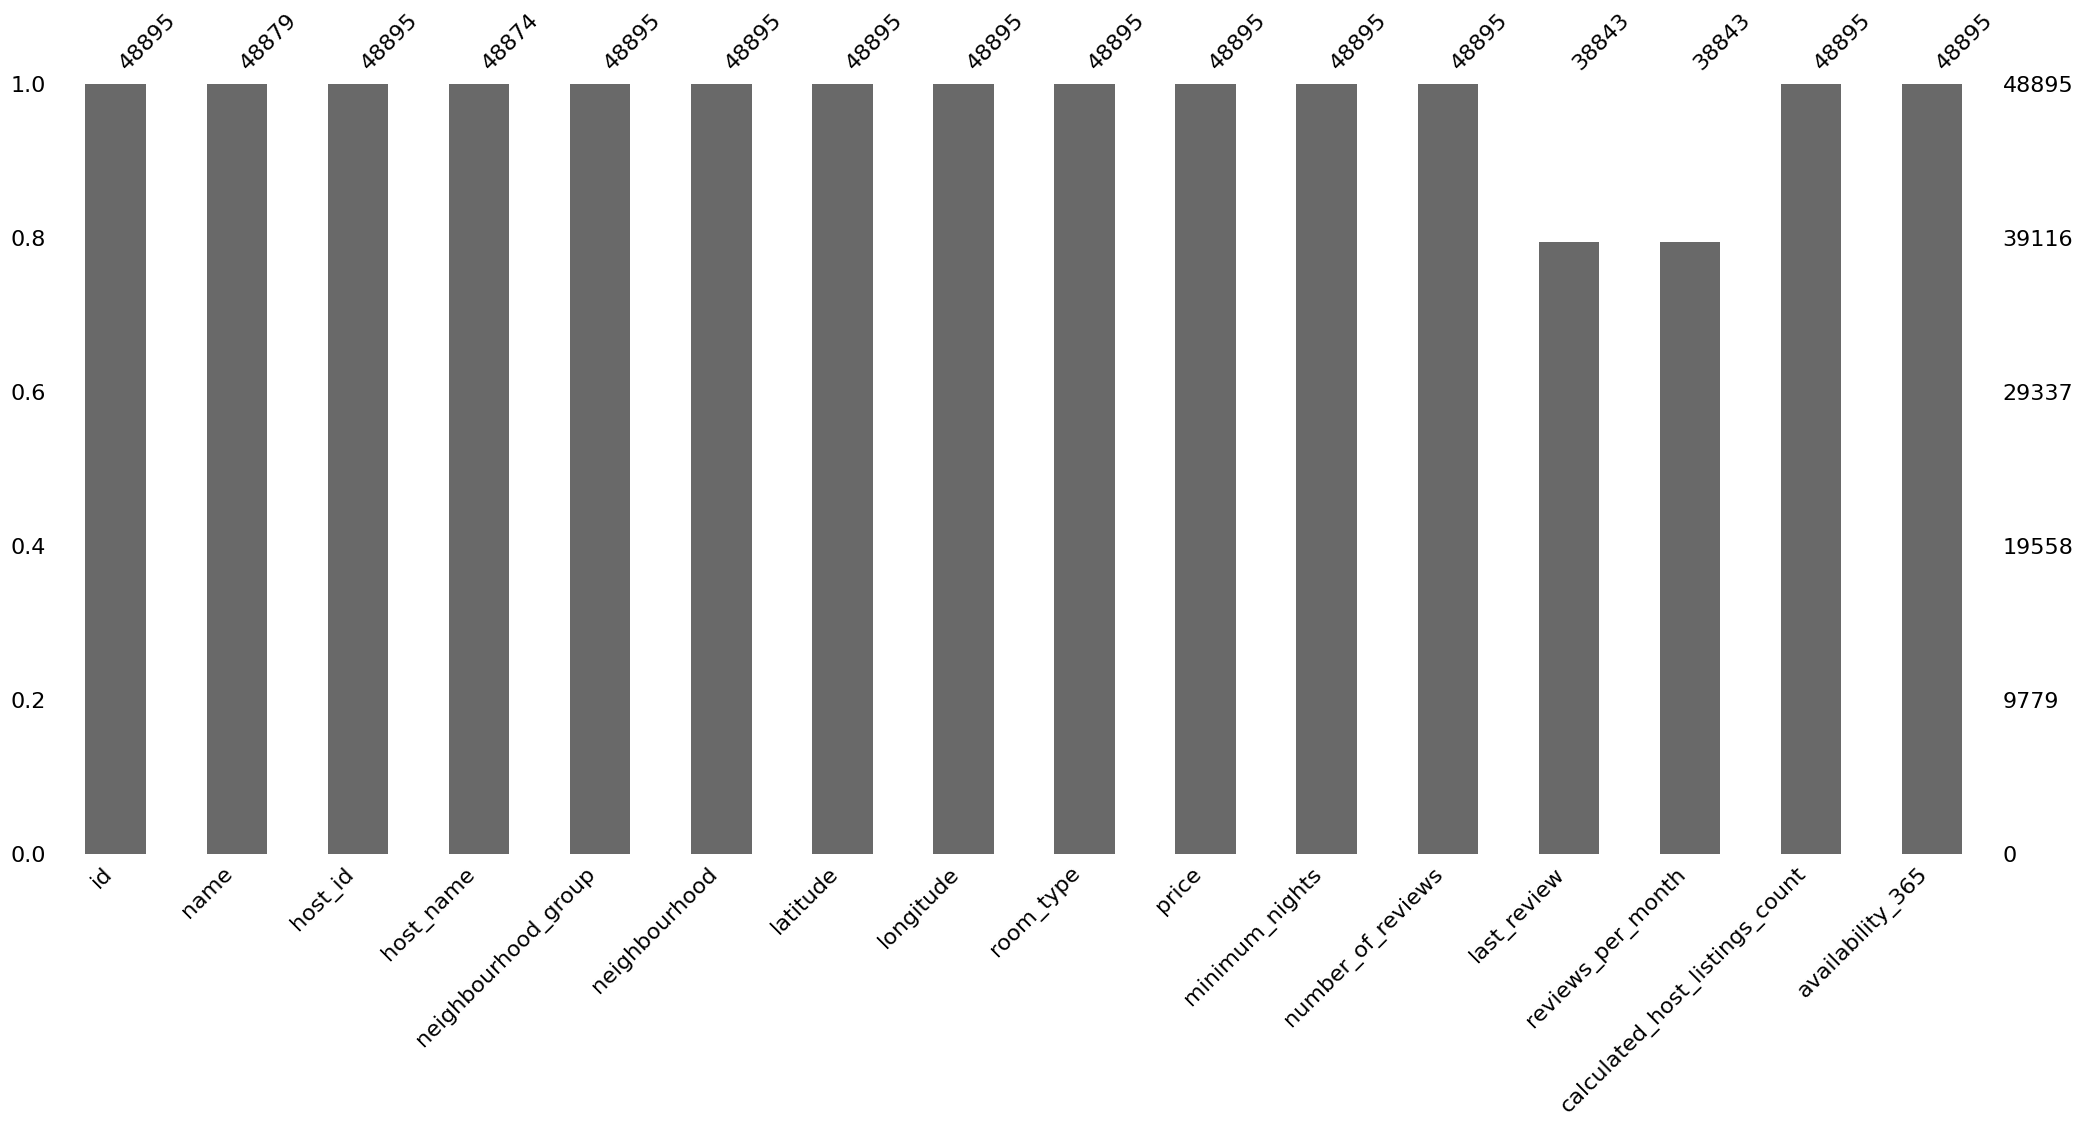

In [9]:
# Visualización de la distribución de valores nulos en el dataset.

msno.bar(df)


<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### **💡 Observación**

La visualización del grafico de valores nulos permite identificar rápidamente la distribución de datos faltantes en el dataset.

Llama la atencion que aunque las variables `name` y `host_name` presentan un porcentaje de valores nulos, casi no se persiben en el grafico y esto ocurre por que su proporción es extremadamente baja en comparación con el tamaño total del dataset (menos del 0.05%), por lo que visualmente apenas se perciben.

Además, `last_review` y `reviews_per_month` presentan el mismo número de valores no nulos, y eso se da justo cuando la variable `number_of_review` es cero como se comprobo anteriormente. 

**En conclusion, el dataset presenta un alto nivel de completitud en la mayoría de las variables, concentrándose los valores faltantes principalmente en las variables relacionadas con la actividad de reseñas.**

</div>

<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### **Data Dictionary**

Para facilitar la interpretación del dataset y apoyar el análisis posterior, se construye un **Data Dictionary** que describe el significado de cada variable.

| Variable | Definition | Key / Values |
|----------|------------|--------------|
| id | Identificador único de cada alojamiento en Airbnb | Integer ID |
| name | Título o nombre del alojamiento | Text |
| host_id | Identificador único del anfitrión | Integer ID |
| host_name | Nombre del anfitrión que ofrece el alojamiento | Text |
| neighbourhood_group | Distrito o zona administrativa donde se encuentra el alojamiento | Manhattan, Brooklyn, Queens, Bronx, Staten Island |
| neighbourhood | Barrio específico dentro del distrito | Example: Harlem, Williamsburg |
| latitude | Latitud geográfica de la ubicación del alojamiento | Decimal coordinate |
| longitude | Longitud geográfica de la ubicación del alojamiento | Decimal coordinate |
| room_type | Tipo de alojamiento ofrecido | Entire home/apt, Private room, Shared room |
| price | Precio por noche en dólares estadounidenses | Numeric |
| minimum_nights | Número mínimo de noches requeridas para reservar | Integer |
| number_of_reviews | Número total de reseñas recibidas | Integer |
| last_review | Fecha de la reseña más reciente | Date |
| reviews_per_month | Número promedio de reseñas por mes | Float |
| calculated_host_listings_count | Número de alojamientos que tiene el anfitrión en Airbnb | Integer |
| availability_365 | Número de días que el alojamiento está disponible durante el año | Integer (0–365) |

</div>


<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### **Paso 2.2: Inspección valores unicos y duplicados**

</div>

In [10]:
# Veamos cuantos valores unicos y no unicos (repetidos) hay en cada variable

df_uniques = df.nunique()
df_repeated = len(df) - df_uniques

resumen = pd.DataFrame({
    'valores_unicos': df_uniques,
    'valores_repetidos': df_repeated
})

resumen

,valores_unicos,valores_repetidos
id,48895,0
name,47905,990
host_id,37457,11438
host_name,11452,37443
neighbourhood_group,5,48890
neighbourhood,221,48674
latitude,19048,29847
longitude,14718,34177
room_type,3,48892
price,674,48221


<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### **💡 Observación**

El análisis de valores únicos y repetidos muestra que la variable `id` presenta valores completamente únicos, mientras que el resto de variables contienen distintos niveles de repetición.

Se observa que algunas variables presentan un número reducido de valores únicos, mientras que otras, como `price`, `number_of_reviews` o `availability_365`, muestran una mayor diversidad de valores.

Asimismo, variables como `host_id` y `name` presentan un número significativo de valores repetidos, lo que sugiere la existencia de posibles relaciones entre registros que requerirán un análisis más detallado en pasos posteriores.

</div>

In [11]:
# Veamos si existen filas completamente identicas (duplicadas) en el dataset 
df.drop(columns=['id']).duplicated().sum()

# NOTA_1: se elimina la columna 'id' por que esta identifica univocamente cada registro lo qu enunca nos permitiria identificar duplicados por fila
# NOTA_2: Este paso crea una copia temporal de dataset en memoria y sobre esa se cuentan los duplicados de las filas

np.int64(0)

<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### **💡 Observación**

Tras excluir la variable `id` del análisis, se confirma que no existen filas completamente duplicadas en el dataset. 

Esto indica que cada registro contiene información única en términos de sus variables descriptivas, reforzando la calidad y consistencia del conjunto de datos.

</div>

In [12]:
# Mostrar los name que se repiten, ordenados y agrupados

names_duplicados = df[df['name'].duplicated(keep=False)].copy()

names_duplicados = names_duplicados.sort_values(by='name')

names_duplicados

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
34347,27237604,*NO GUEST SERVICE FEE* Luxury Midtown One Bedr...,205031545,Red Awning,Manhattan,Midtown,40.75294,-73.96731,Entire home/apt,737,3,2,2019-06-07,0.40,49,235
34352,27237625,*NO GUEST SERVICE FEE* Luxury Midtown One Bedr...,205031545,Red Awning,Manhattan,Midtown,40.75459,-73.96707,Entire home/apt,737,3,3,2019-06-10,0.44,49,153
42817,33241978,1 BR Suite in Midtown Manhattan,24831061,Hosteeva,Manhattan,Midtown,40.76391,-73.98071,Private room,250,1,0,NaN,NaN,8,0
42776,33216329,1 BR Suite in Midtown Manhattan,24831061,Hosteeva,Manhattan,Midtown,40.76453,-73.98035,Private room,250,1,0,NaN,NaN,8,0
7946,6101104,1 BR UPPER EAST SIDE,9107715,Michele,Manhattan,Upper East Side,40.77526,-73.95075,Entire home/apt,170,5,26,2019-05-18,0.55,1,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13401,10052289,NaN,49522403,Vanessa,Brooklyn,Brownsville,40.66409,-73.92314,Private room,50,3,3,2016-08-18,0.07,1,362
15819,12797684,NaN,69715276,Yan,Manhattan,Upper West Side,40.79843,-73.96404,Private room,100,1,0,NaN,NaN,2,0
16071,12988898,NaN,71552588,Andrea,Bronx,Fordham,40.86032,-73.88493,Shared room,130,1,0,NaN,NaN,1,365
18047,14135050,NaN,85288337,Jeff,Brooklyn,Bedford-Stuyvesant,40.69421,-73.93234,Private room,70,3,0,NaN,NaN,1,0



<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### **💡 Observación**

Se observa que existen múltiples registros con el mismo valor en la variable `name`. Sin embargo, al analizar estos casos en detalle, se identifican diferencias en variables como `latitude` y `longitude`, lo que indica que no se trata del mismo alojamiento.

Esto sugiere que el nombre del listing es un campo descriptivo que puede repetirse entre distintos alojamientos, por lo que no puede utilizarse como identificador único.

</div>

In [13]:
# Mostrar los host_id que se repiten, ordenados y agrupados
hosts_duplicados = df[df['host_id'].duplicated(keep=False)] \
                    .sort_values(by=['host_id'])

hosts_duplicados.head(25)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
10372,7937553,Riomaggiore Room. Queen Bedroom in Bklyn Townh...,2787,John,Brooklyn,Bensonhurst,40.60951,-73.97622,Private room,99,1,21,2018-10-27,0.50,6,153
21556,17263207,Brooklyn home. Comfort and clean. Liguria room.,2787,John,Brooklyn,Bensonhurst,40.60877,-73.97382,Private room,49,1,19,2019-06-08,0.70,6,360
13963,10593675,"La Spezia room. Clean, quiet and comfortable bed",2787,John,Brooklyn,Bensonhurst,40.60951,-73.97642,Shared room,79,1,15,2018-09-29,0.43,6,180
13688,10267242,Cinque Terre Room. Clean and Quiet Queen Bedroom,2787,John,Brooklyn,Gravesend,40.60810,-73.97541,Private room,149,1,24,2019-05-11,0.64,6,180
13583,10160215,Torre del Lago Room.,2787,John,Brooklyn,Gravesend,40.60755,-73.97410,Private room,79,1,17,2019-06-26,0.40,6,174
22728,18393354,Midtown Sanctuary,2845,Jennifer,Manhattan,Midtown,40.75358,-73.99190,Shared room,99,1,1,2018-07-18,0.08,2,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
7875,6027345,Newly renovated historic brownstone,2881,Loli,Brooklyn,Bedford-Stuyvesant,40.68242,-73.94774,Private room,65,2,280,2019-07-05,5.51,2,249
8302,6385039,Historic room in renovated brownstone,2881,Loli,Brooklyn,Bedford-Stuyvesant,40.68473,-73.94600,Private room,52,2,110,2019-07-01,2.63,2,220


In [14]:
# Ver solo los hosts que tienen más de un alojamiento
hosts_multi = df['host_id'].value_counts()
hosts_multi = hosts_multi[hosts_multi > 1]

# Convertir a DataFrame
hosts_multi_df = hosts_multi.reset_index()
hosts_multi_df.columns = ['host_id', 'num_listings']

hosts_multi_df


,host_id,num_listings
0,219517861,327
1,107434423,232
2,30283594,121
3,137358866,103
4,16098958,96
...,...,...
5149,266211707,2
5150,6570630,2
5151,274012871,2
5152,272265577,2



<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### **💡 Observación**

El análisis de la variable `host_id` muestra que existen anfitriones que gestionan múltiples alojamientos, identificándose casos con más de una propiedad asociada e incluso algunos con un número elevado de listings.

Este comportamiento confirma que la relación entre anfitrión y alojamiento es de tipo uno a muchos (1:N), donde un mismo host puede gestionar varios listings dentro del dataset.

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### **Paso 2.3: Análisis estadístico descriptivo**

</div>

In [15]:
# Se calculan estadísticas descriptivo para las variables numericas comprender su distribución, rango de valores y posibles valores outliers

df.describe().style.format("{:.4f}")

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.0000,48895.0000,48895.0000,48895.0000,48895.0000,48895.0000,48895.0000,38843.0000,48895.0000,48895.0000
mean,19017143.2362,67620010.6466,40.7289,-73.9522,152.7207,7.0300,23.2745,1.3732,7.1440,112.7813
std,10983108.3856,78610967.0327,0.0545,0.0462,240.1542,20.5105,44.5506,1.6804,32.9525,131.6223
min,2539.0000,2438.0000,40.4998,-74.2444,0.0000,1.0000,0.0000,0.0100,1.0000,0.0000
25%,9471945.0000,7822033.0000,40.6901,-73.9831,69.0000,1.0000,1.0000,0.1900,1.0000,0.0000
50%,19677284.0000,30793816.0000,40.7231,-73.9557,106.0000,3.0000,5.0000,0.7200,1.0000,45.0000
75%,29152178.5000,107434423.0000,40.7631,-73.9363,175.0000,5.0000,24.0000,2.0200,2.0000,227.0000
max,36487245.0000,274321313.0000,40.9131,-73.7130,10000.0000,1250.0000,629.0000,58.5000,327.0000,365.0000


<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### **💡 Observación**

El análisis descriptivo de las variables numéricas muestra una alta dispersión en la mayoría de ellas, con diferencias significativas entre los valores mínimos, medianos y máximos.

En particular, variables como `price` y `minimum_nights` presentan valores extremos que sugieren la presencia de outliers. Además, se identifican valores atípicos como precios iguales a 0 o noches mínimas excesivamente elevadas, que podrían indicar errores en los datos o comportamientos poco representativos.

Este comportamiento indica que será necesario profundizar en el análisis de la distribución de estas variables mediante visualizaciones (como histogramas o boxplots) para comprender mejor su comportamiento y evaluar posibles tratamientos posteriores.

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### **Paso 2.4: Análisis univariable de variables numéricas**

</div>

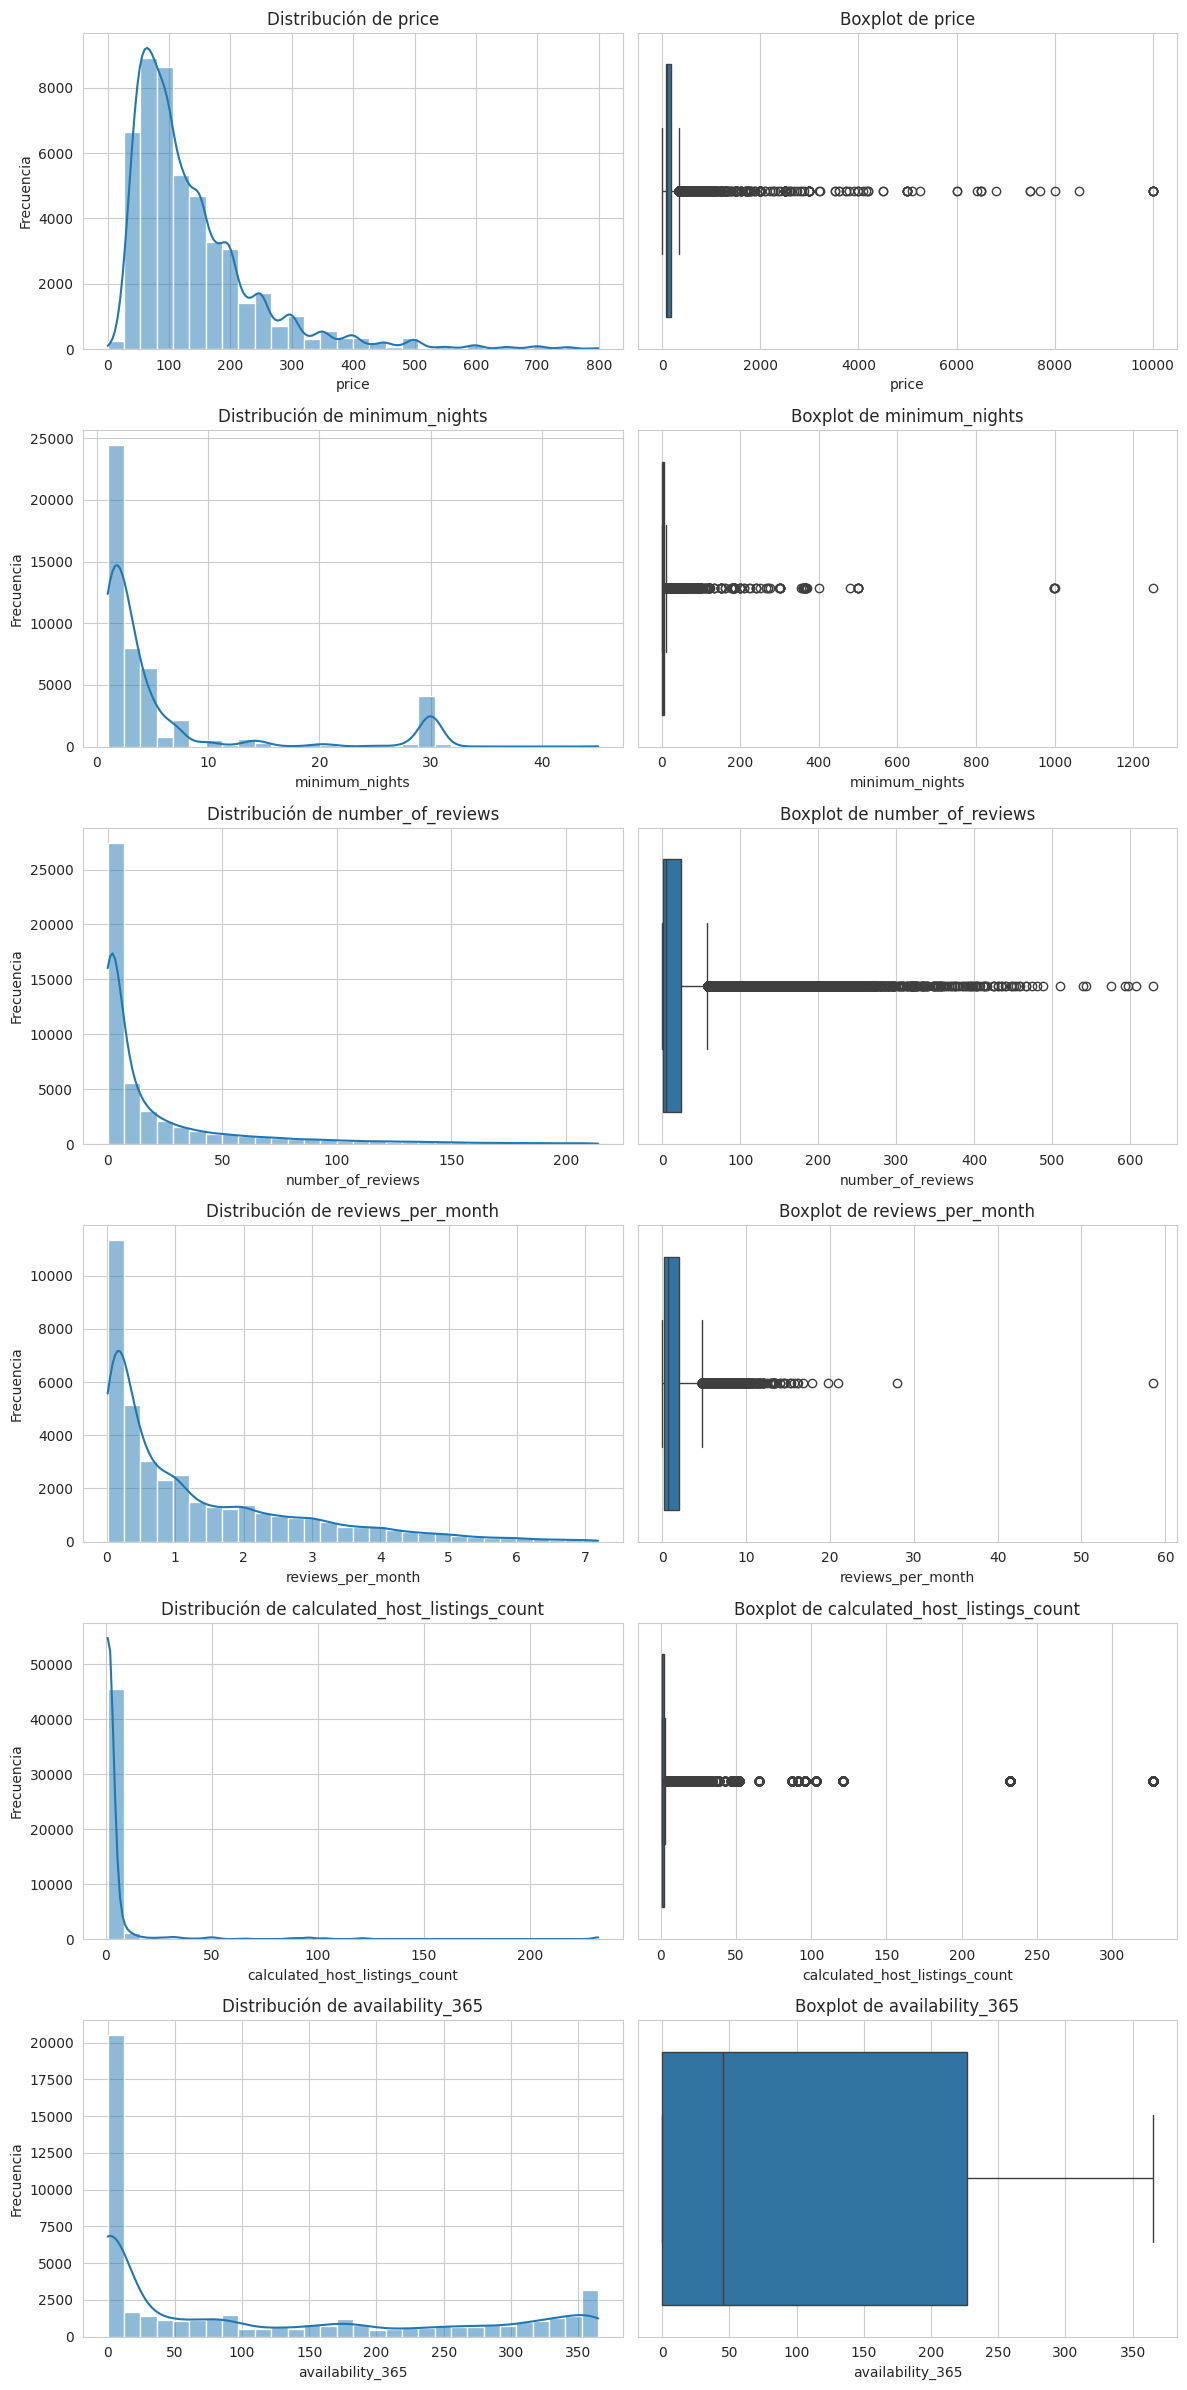

In [18]:
# Seleccionamos automáticamente las variables numéricas
num_vars = df.select_dtypes(include=['int64', 'float64']).columns

# Seleccionamos variables numéricas excluyendo las no relevantes
num_vars = df.select_dtypes(include=['int64', 'float64']).columns
num_vars = num_vars.drop(['id', 'host_id', 'latitude', 'longitude'])

# Estilo limpio
sns.set_style("whitegrid")

# Tamaño más equilibrado (menos achatado)
fig, axes = plt.subplots(len(num_vars), 2, figsize=(12, 4 * len(num_vars)))

for i, col in enumerate(num_vars):

    # Para evitar que los outliers "aplasten" el histograma
    upper_limit = df[col].quantile(0.99)
    data = df[df[col] <= upper_limit][col]

    # Histograma
    sns.histplot(data, bins=30, ax=axes[i, 0], kde=True)
    axes[i, 0].set_title(f"Distribución de {col}")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Frecuencia")

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot de {col}")
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### **💡 Observación**

Las variables numéricas presentan distribuciones fuertemente sesgadas hacia la derecha, con una alta concentración de valores bajos y colas largas de valores elevados.

Este comportamiento provoca que los boxplots identifiquen un gran número de valores como posibles outliers, lo cual no necesariamente indica errores en los datos, sino la presencia de distribuciones no normales.

Estos resultados son coherentes con el análisis estadístico descriptivo previo, donde se observaba que la desviación estándar superaba en muchos casos a la media, reflejando una alta dispersión en los datos.

</div>


<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### **Paso 2.5: Análisis univariable de variables categóricas**

</div>

In [17]:
# Se seleccionan las posibles variables categóricas
cat_vars = df.select_dtypes(include=['object', 'string']).columns

# Creamos un resumen más legible de las variables categóricas
cat_summary = pd.DataFrame({
    "variable": cat_vars,
    "n_valores_unicos": [df[col].nunique() for col in cat_vars],
    "valores": [", ".join(map(str, df[col].dropna().unique())) for col in cat_vars]
})

cat_summary

,variable,n_valores_unicos,valores
0,name,47905,"Clean & quiet apt home by the park, Skylit Mid..."
1,host_name,11452,"John, Jennifer, Elisabeth, LisaRoxanne, Laura,..."
2,neighbourhood_group,5,"Brooklyn, Manhattan, Queens, Staten Island, Bronx"
3,neighbourhood,221,"Kensington, Midtown, Harlem, Clinton Hill, Eas..."
4,room_type,3,"Private room, Entire home/apt, Shared room"
5,last_review,1764,"2018-10-19, 2019-05-21, 2019-07-05, 2018-11-19..."


<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### 💡 **Observación**

Las variables categóricas se identifican combinando su tipo de dato, el número de valores únicos y su significado dentro del dataset.

En este caso, se observan dos comportamientos diferenciados:

- Variables con bajo número de valores únicos (baja cardinalidad), como `neighbourhood_group` y `room_type`, que representan categorías bien definidas y son adecuadas para su análisis mediante distribuciones agregadas.

- Variables con alto número de valores únicos (alta cardinalidad), como `name`, `host_name` o `neighbourhood`, que aunque son de tipo texto, contienen demasiados valores distintos, lo que dificulta su análisis como categorías agregadas.

Por otro lado, la variable `last_review`, aunque está en formato fecha (`datetime`), no representa categorías sino información temporal. Podría transformarse en variables derivadas (por ejemplo, rangos de fechas o antigüedad) si se quisiera analizar el comportamiento temporal de los alojamientos. Sin embargo, en este EDA exploratorio se mantiene como una variable temporal sin transformación.

👉 A continuación, el análisis se centrará en las variables con menor cardinalidad, ya que permiten una interpretación más clara y directa de su distribución.

</div>

<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### 💡 **Observación sobre el orden en las variables categoricas**

Las variables categóricas analizadas (`neighbourhood_group` y `room_type`) **se consideran variables no ordenadas (nominales), ya que no existe una jerarquía natural entre sus categorías.**

Aunque en el caso de `room_type` podría interpretarse un cierto orden en términos de privacidad o precio, este no forma parte de la estructura intrínseca del dataset, por lo que no se trata como variable ordinal.

</div>

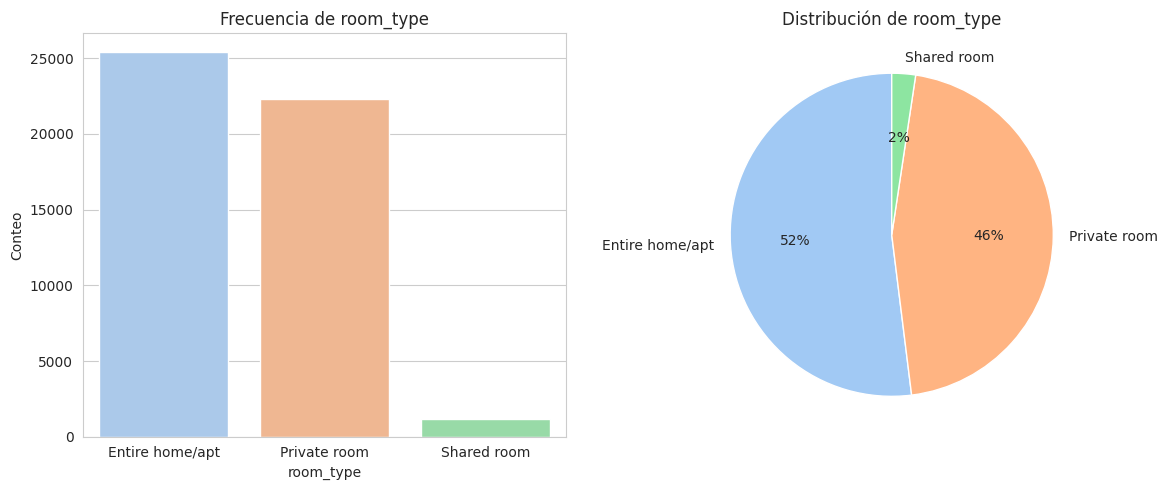

In [24]:
# Orden consistente
order = df['room_type'].value_counts().index

# Datos
data = df['room_type'].value_counts(normalize=True)

# Crear diccionario de colores fijo
palette = dict(zip(order, sns.color_palette('pastel', len(order))))

# Figura
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# 🔹 Countplot (sin warning y colores correctos)
sns.countplot(
    x='room_type',
    data=df,
    order=order,
    hue='room_type',
    palette=palette,
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Frecuencia de room_type')
axes[0].set_xlabel('room_type')
axes[0].set_ylabel('Conteo')

# 🔹 Pie chart (mismos colores)
axes[1].pie(
    data,
    labels=data.index,
    colors=[palette[i] for i in data.index],
    autopct='%1.0f%%',
    startangle=90
)

axes[1].set_title('Distribución de room_type')

plt.tight_layout()
plt.show()

<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### 💡 **Observación**

Se observa que la mayoría de los alojamientos alquilados en 2019 corresponden a `Entire home/apt` y `Private room`, mientras que `Shared room` tiene una representación muy baja en el dataset.

Esto indica que el mercado en ese año estaba claramente dominado por opciones de mayor privacidad.

</div>

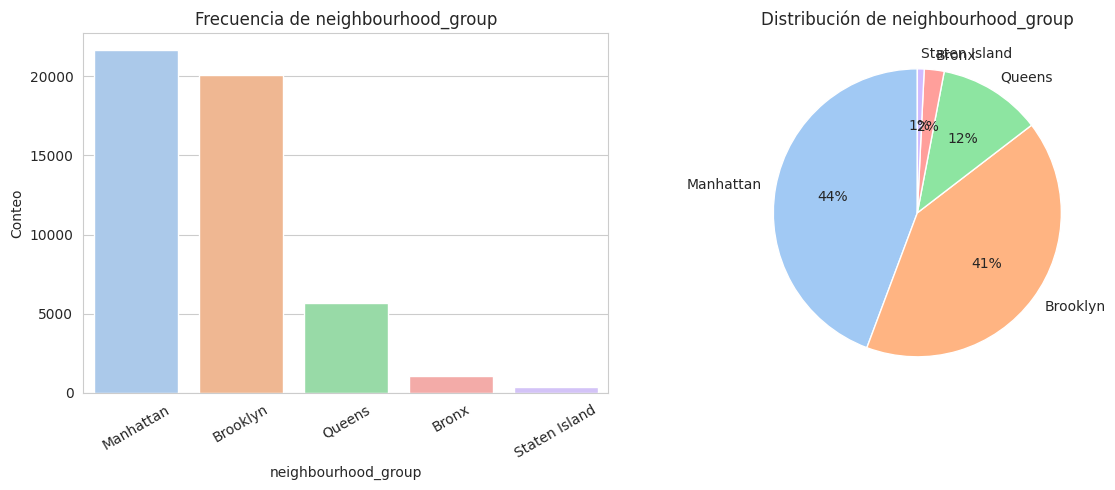

In [25]:
# Orden consistente
order = df['neighbourhood_group'].value_counts().index

# Datos
data = df['neighbourhood_group'].value_counts(normalize=True)

# Paleta consistente
palette = dict(zip(order, sns.color_palette('pastel', len(order))))

# Figura
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# 🔹 Countplot
sns.countplot(
    x='neighbourhood_group',
    data=df,
    order=order,
    hue='neighbourhood_group',
    palette=palette,
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Frecuencia de neighbourhood_group')
axes[0].set_xlabel('neighbourhood_group')
axes[0].set_ylabel('Conteo')
axes[0].tick_params(axis='x', rotation=30)

# 🔹 Pie chart
axes[1].pie(
    data,
    labels=data.index,
    colors=[palette[i] for i in data.index],
    autopct='%1.0f%%',
    startangle=90
)

axes[1].set_title('Distribución de neighbourhood_group')

plt.tight_layout()
plt.show()

<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### 💡 Observación

Se observa una distribución desigual entre los grupos de vecindario, concentrándose la mayor parte de los alojamientos en Manhattan y Brooklyn.

Esto sugiere que la oferta no estaba homogéneamente distribuida en la ciudad.

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### **Paso 2.6: Análisis Bivariado**

</div>